# Compare Skeleton Metrics Across Datasets

Loads every `results.csv` written by `evaluate_skeleton_metrics.ipynb` under
`metrics_out/<brain_id>/<segmentation_id>/` and compares the per-neuron skeleton
metrics **across datasets** (brain / segmentation pairs).

The question this answers: **is the automated reconstruction's error profile
consistent from one dataset to the next, or does some brain stand out?**

We focus on the *scale-normalized* metrics (percentages, accuracy, normalized
ERL) for cross-dataset comparison — raw counts like `# Splits` scale with neuron
size and aren't directly comparable across brains.

Kernel: **panda**.

## 1. Discover and load all results

In [1]:
import glob
import os

import numpy as np
import pandas as pd

METRICS_ROOT = "../metrics_out"

# Each run lives at metrics_out/<brain_id>/<segmentation_id>/results.csv
result_paths = sorted(glob.glob(os.path.join(METRICS_ROOT, "*", "*", "results.csv")))
assert result_paths, f"No results.csv found under {METRICS_ROOT}"

frames = {}
for path in result_paths:
    seg_dir = os.path.dirname(path)
    segmentation_id = os.path.basename(seg_dir)
    brain_id = os.path.basename(os.path.dirname(seg_dir))
    df = pd.read_csv(path, index_col=0)
    df.index.name = "neuron"
    frames[brain_id] = df
    print(f"{brain_id:>8}  {segmentation_id:<55}  {len(df):>3} neurons, {df.shape[1]} metrics")

datasets = list(frames)
metrics = list(next(iter(frames.values())).columns)
print(f"\n{len(datasets)} datasets, metrics: {metrics}")

  789202  raw.unet_r3_ckpt_425250_seedfix_overlapfix_rempm          12 neurons, 11 metrics
  794491  mean40.stddev105.mask.136168199.no_omitted_20k.ffn.mt_0.1    9 neurons, 11 metrics
  794492  denoised.unet_r3_ckpt_155250                              53 neurons, 11 metrics
  794493  mean40.stddev105.mask.136168199.no_omitted_20k.ffn.mt_0.1   10 neurons, 11 metrics
  794495  raw.unet_449_792_202_splits_and_merges_831600             19 neurons, 11 metrics
  802449  raw.unet_r3_ckpt_425250_seedfix_overlapfix                38 neurons, 11 metrics

6 datasets, metrics: ['SWC Run Length', '# Splits', '# Merges', '% Split Edges', '% Omit Edges', '% Merged Edges', 'ERL', 'Normalized ERL', 'Edge Accuracy', 'Split Rate', 'Merge Rate']


## 2. Per-dataset summary (means)

One row per dataset, the mean of each metric across that dataset's neurons — the
same averages `evaluate_skeleton_metrics.ipynb` prints in `results_overview.txt`,
lined up side by side so differences are obvious.

In [2]:
summary = pd.DataFrame(
    {brain_id: df.mean(numeric_only=True) for brain_id, df in frames.items()}
).T
summary.index.name = "brain_id"
summary.insert(0, "n_neurons", [len(frames[b]) for b in summary.index])
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
summary

,n_neurons,SWC Run Length,# Splits,# Merges,% Split Edges,% Omit Edges,% Merged Edges,ERL,Normalized ERL,Edge Accuracy,Split Rate,Merge Rate
brain_id,,,,,,,,,,,,
789202,12,"717,921.471",837.417,8.250,0.361,3.168,13.266,"4,022.817",0.007,83.206,930.587,"140,967.578"
794491,9,"394,199.139","1,263.111",16.444,0.812,2.718,22.017,"2,700.520",0.007,74.453,417.183,"41,636.540"
794492,53,"438,667.130",937.415,41.774,0.532,15.886,12.073,899.386,0.002,71.510,403.105,"21,544.682"
794493,10,"361,001.081","1,242.000",5.100,0.940,3.771,14.424,"1,806.367",0.006,80.865,341.940,"62,468.148"
794495,19,"440,498.555",566.316,8.842,0.339,1.642,28.442,"9,057.972",0.021,69.577,860.095,"87,774.523"
802449,38,"386,035.757",512.447,33.658,0.331,2.037,36.762,"2,711.408",0.008,60.871,814.178,"22,637.985"


## 3. Consistency across datasets

For each metric we compare the per-dataset means and report the **coefficient of
variation** (CV = std / |mean| across datasets). Low CV → the datasets agree on
that metric; high CV → the error profile differs between brains.

We flag the scale-normalized metrics (the ones meaningfully comparable across
brains of different size) and rank them by CV.

In [3]:
# Metrics that are comparable across brains regardless of size.
NORMALIZED = [
    "% Split Edges", "% Omit Edges", "% Merged Edges",
    "Edge Accuracy", "Normalized ERL",
]

across = pd.DataFrame({
    "mean_of_means": summary[metrics].mean(),
    "std_across_datasets": summary[metrics].std(ddof=0),
    "min": summary[metrics].min(),
    "max": summary[metrics].max(),
})
across["CV"] = across["std_across_datasets"] / across["mean_of_means"].abs()
across["scale_normalized"] = across.index.isin(NORMALIZED)
across = across.sort_values("CV", ascending=False)

print("Cross-dataset consistency (lower CV = more consistent):\n")
display(across)

norm_cv = across.loc[across["scale_normalized"], "CV"]
print(f"\nScale-normalized metrics: CV ranges {norm_cv.min():.2f}–{norm_cv.max():.2f}")
print(f"  most consistent: {norm_cv.idxmin()} (CV={norm_cv.min():.2f})")
print(f"  least consistent: {norm_cv.idxmax()} (CV={norm_cv.max():.2f})")

Cross-dataset consistency (lower CV = more consistent):



,mean_of_means,std_across_datasets,min,max,CV,scale_normalized
% Omit Edges,4.870,4.975,1.642,15.886,1.022,True
ERL,"3,533.078","2,647.340",899.386,"9,057.972",0.749,False
# Merges,19.011,13.856,5.100,41.774,0.729,False
Normalized ERL,0.009,0.006,0.002,0.021,0.676,True
Merge Rate,"62,838.242","41,826.784","21,544.682","140,967.578",0.666,False
% Split Edges,0.552,0.241,0.331,0.940,0.437,True
% Merged Edges,21.164,9.013,12.073,36.762,0.426,True
Split Rate,627.848,243.906,341.940,930.587,0.388,False
# Splits,893.118,293.084,512.447,"1,263.111",0.328,False
SWC Run Length,"456,387.189","120,334.130","361,001.081","717,921.471",0.264,False



Scale-normalized metrics: CV ranges 0.10–1.02
  most consistent: Edge Accuracy (CV=0.10)
  least consistent: % Omit Edges (CV=1.02)


## 4. Per-neuron distributions

The summary above compares dataset *means*; this shows the full per-neuron spread
so you can see whether the datasets overlap or separate. Each panel is one
normalized metric; each box is one dataset (dots = individual neurons).

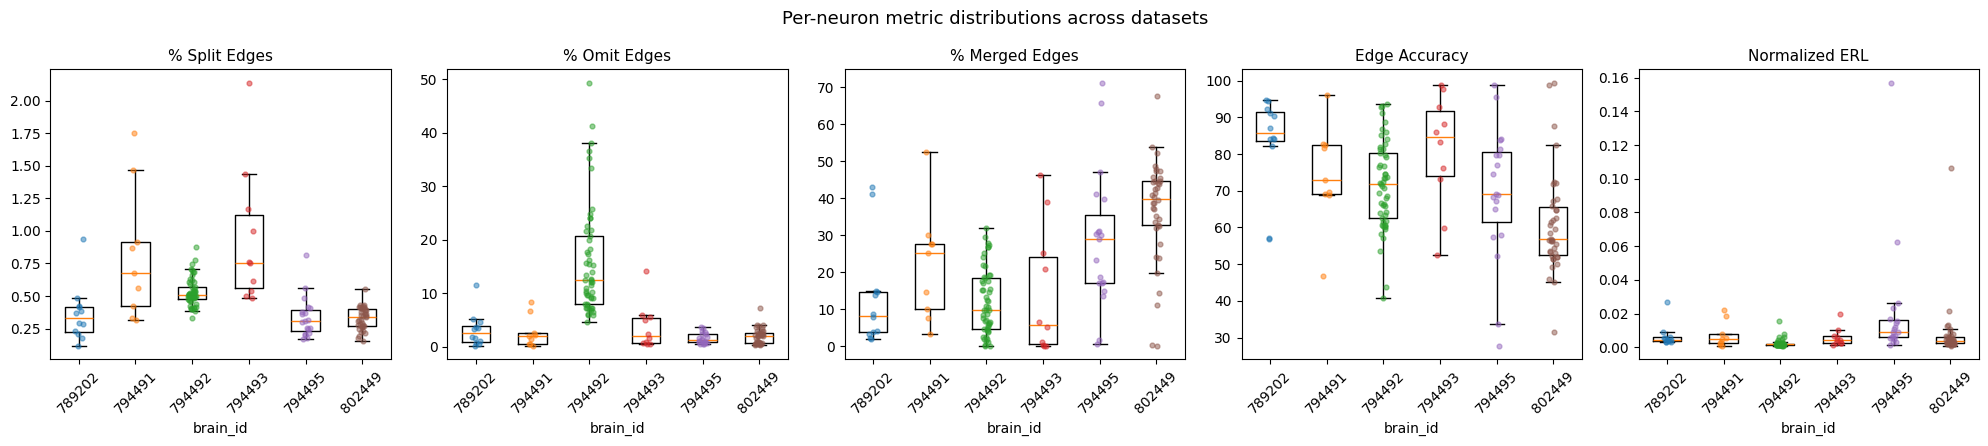

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(NORMALIZED), figsize=(4 * len(NORMALIZED), 4.5))
for ax, metric in zip(np.atleast_1d(axes), NORMALIZED):
    data = [frames[b][metric].values for b in datasets]
    ax.boxplot(data, tick_labels=datasets, showfliers=False)
    for i, vals in enumerate(data, start=1):
        jitter = (np.random.default_rng(i).random(len(vals)) - 0.5) * 0.15
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=12, alpha=0.5, zorder=3)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("brain_id")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Per-neuron metric distributions across datasets", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Verdict

A compact, automatic read of how consistent the datasets are on each normalized
metric — using the coefficient of variation of the per-dataset means as a rough
threshold (CV < 0.25 ≈ consistent, otherwise the brains diverge there).

In [5]:
if len(datasets) < 2:
    print(f"Only one dataset ({datasets[0]}) — nothing to compare. "
          "Run evaluate_skeleton_metrics.ipynb on another brain first.")
else:
    print(f"Comparing {len(datasets)} datasets: {', '.join(datasets)}\n")
    for metric in NORMALIZED:
        cv = across.loc[metric, "CV"]
        lo, hi = across.loc[metric, "min"], across.loc[metric, "max"]
        verdict = "consistent" if cv < 0.25 else "DIVERGES"
        print(f"  {metric:<16} CV={cv:5.2f}  [{lo:.3g} .. {hi:.3g}]  -> {verdict}")
    print("\nNote: counts (# Splits/# Merges, Split/Merge Rate) scale with neuron")
    print("size, so cross-brain differences there are expected, not inconsistency.")

Comparing 6 datasets: 789202, 794491, 794492, 794493, 794495, 802449

  % Split Edges    CV= 0.44  [0.331 .. 0.94]  -> DIVERGES
  % Omit Edges     CV= 1.02  [1.64 .. 15.9]  -> DIVERGES
  % Merged Edges   CV= 0.43  [12.1 .. 36.8]  -> DIVERGES
  Edge Accuracy    CV= 0.10  [60.9 .. 83.2]  -> consistent
  Normalized ERL   CV= 0.68  [0.00242 .. 0.0208]  -> DIVERGES

Note: counts (# Splits/# Merges, Split/Merge Rate) scale with neuron
size, so cross-brain differences there are expected, not inconsistency.
